In [2]:
%pip install tensorflow matplotlib scikit-learn

   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
    --------------------------------------- 6.6/384.1 MB 38.9 MB/s eta 0:00:10
   - -------------------------------------- 15.5/384.1 MB 38.2 MB/s eta 0:00:10
   -- ------------------------------------- 27.5/384.1 MB 45.4 MB/s eta 0:00:08
   ---- ----------------------------------- 43.0/384.1 MB 52.8 MB/s eta 0:00:07
   ------ --------------------------------- 60.0/384.1 MB 58.7 MB/s eta 0:00:06
   ------- -------------------------------- 68.4/384.1 MB 57.2 MB/s eta 0:00:06
   -------- ------------------------------- 81.0/384.1 MB 56.5 MB/s eta 0:00:06
   --------- ------------------------------ 95.7/384.1 MB 58.4 MB/s eta 0:00:05
   ----------- --------------------------- 112.5/384.1 MB 60.8 MB/s eta 0:00:05
   ------------- ------------------------- 129.0/384.1 MB 62.8 MB/s eta 0:00:05
   -------------- ------------------------ 146.3/384.1 MB 64.7 MB/s eta 0:00:04
   ---------------- ---------------------- 163.8/3

In [3]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [4]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1244s 7us/step


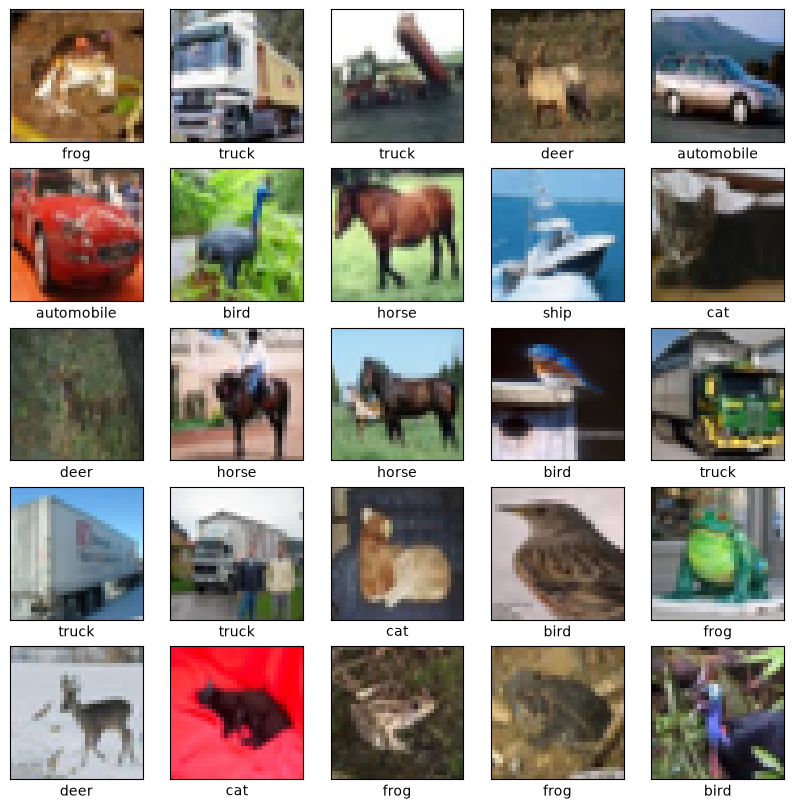

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [7]:
model = models.Sequential()

model.add(layers.Input(shape=(32, 32, 3)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4520 - loss: 1.4993 - val_accuracy: 0.5670 - val_loss: 1.2007
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5937 - loss: 1.1412 - val_accuracy: 0.6186 - val_loss: 1.0628
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6480 - loss: 0.9982 - val_accuracy: 0.6480 - val_loss: 0.9969
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6824 - loss: 0.9048 - val_accuracy: 0.6602 - val_loss: 0.9792
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7090 - loss: 0.8312 - val_accuracy: 0.6713 - val_loss: 0.9522


313/313 - 1s - 4ms/step - accuracy: 0.6713 - loss: 0.9522


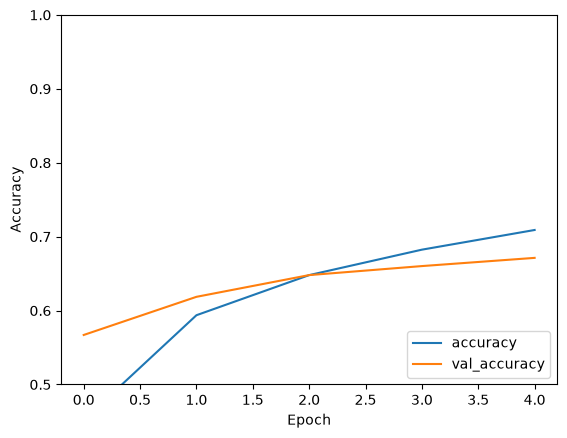

In [12]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [13]:
print(test_acc)

0.6712999939918518


In [14]:
import os

os.makedirs("../results/EXP-01", exist_ok=True)

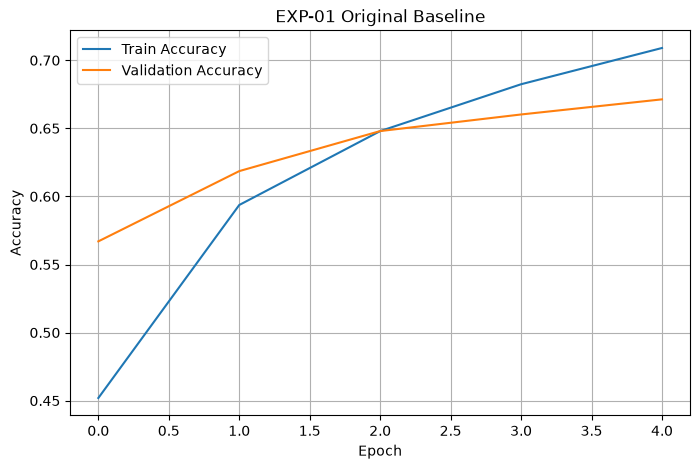

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('EXP-01 Original Baseline')
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/EXP-01/accuracy.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

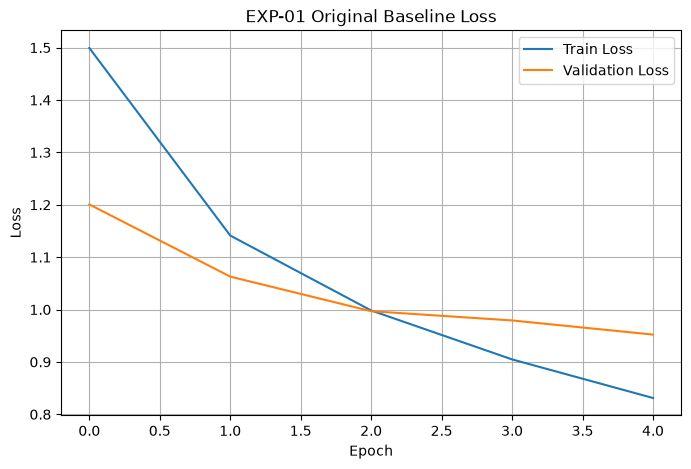

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('EXP-01 Original Baseline Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/EXP-01/loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [20]:
result_text = """
Experiment: EXP-01 Original Baseline

Dataset: CIFAR-10

Model:
Conv2D 32
MaxPooling
Conv2D 64
MaxPooling
Conv2D 64
Flatten
Dense 64
Dense 10

Optimizer: Adam
Epochs: 5

Train Accuracy: 70.90%
Validation/Test Accuracy: 67.13%

Train Loss: 0.8312
Validation/Test Loss: 0.9522

Note:
Original professor practice code.
Test dataset was also used as validation data.
Therefore this experiment is preserved as a historical baseline
and will not be used as the final fair comparison result.
"""

with open(
    "../results/EXP-01/result.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)